# RoadGuard: Comprehensive Experimental Evaluation (Fixed v10 - Hardened)
**Project Context**: Master's Thesis in Computer Science Engineering (Sapienza University of Rome)
**Dataset**: Thessaloniki & Larisa Road Quality Dataset
**Objective**: Optimized 100-epoch training and real-world evaluation with Drive backups.

---

## 1. Environment Setup
Mounting Drive and installing dependencies.

In [1]:
!pip install ultralytics kaggle scikit-learn matplotlib pandas numpy tensorflow tf_keras -q
from google.colab import drive
import os, shutil, glob, zipfile, pickle, gc
from IPython.display import Image, display
import pandas as pd
import numpy as np

drive.mount('/content/drive')
DRIVE_SAVE_DIR = '/content/drive/MyDrive/RoadGuard_Thesis_Backups'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

if not os.path.exists('/content/RoadGuard'):
    !git clone https://github.com/antoninofoti/RoadGuard.git /content/RoadGuard
else:
    %cd /content/RoadGuard
    !git pull
    %cd /content

print('Environment and Drive Backup system ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:00
Mounted at /content/drive
Cloning into '/content/RoadGuard'...
remote: Enumerating objects: 2126, done.
remote: Counting objects: 100% (224/224), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 2126 (delta 54), reused 163 (delta 45), pack-reused 1902 (from 2)
Receiving objects: 100% (2126/2126), 330.35 MiB | 19.78 MiB/s, done.
Resolving deltas: 100% (653/653), done.
Updating files: 100% (1295/1295), done.
Environment and Drive Backup system ready.


## 2. Dataset Acquisition & Incremental Synchronization
Processing real-world recordings with memory-efficient incremental persistence.

In [4]:
from google.colab import files
if not os.path.exists('kaggle.json'):
    print("Action Required: Please upload your kaggle.json file")
    uploaded = files.upload()

os.makedirs('/root/.config/kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

THESSALONIKI_DIR = '/content/data/thessaloniki'
!mkdir -p {THESSALONIKI_DIR}
!kaggle datasets download nickkotarelas/road-quality-dataset -p {THESSALONIKI_DIR} --unzip

IMU_OUTPUT = os.path.join(THESSALONIKI_DIR, 'imu_normalized.csv')
VISION_OUTPUT = os.path.join(THESSALONIKI_DIR, 'frame_labels.csv')
if os.path.exists(IMU_OUTPUT): os.remove(IMU_OUTPUT)
if os.path.exists(VISION_OUTPUT): os.remove(VISION_OUTPUT)

pkl_files = glob.glob(f'{THESSALONIKI_DIR}/*.pkl')
for pkl_path in pkl_files:
    print(f"Processing session: {os.path.basename(pkl_path)}")
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)

    intervals = data.get('labels', [])

    # IMU
    imu = data.get('imu', {})
    accel, ts = imu.get('accel', []), imu.get('time', [])
    if len(accel) > 0:
        df = pd.DataFrame(accel, columns=['acc_x', 'acc_y', 'acc_z'])
        df['time'] = pd.to_numeric(ts['rel'], errors='coerce').astype(float)
        df['label'] = 0
        for l in intervals:
            s_t, e_t = float(l.get('rel_t_start', 0)), float(l.get('rel_t_end', 0))
            df.loc[(df['time'] >= s_t) & (df['time'] <= e_t), 'label'] = 1
        df.to_csv(IMU_OUTPUT, mode='a', index=False, header=not os.path.exists(IMU_OUTPUT))

    # Vision Metadata
    cam_times = data.get('camera', {}).get('time', [])
    if cam_times:
        v_meta = []
        for i, ct in enumerate(cam_times['rel']):
            curr, is_a = float(ct), 0
            for l in intervals:
                if float(l.get('rel_t_start', 0)) <= curr <= float(l.get('rel_t_end', 0)):
                    is_a = 1; break
            v_meta.append({'filename': f"frame_{i}.jpg", 'label': is_a})
        pd.DataFrame(v_meta).to_csv(VISION_OUTPUT, mode='a', index=False, header=not os.path.exists(VISION_OUTPUT))

    del data; gc.collect()

print('Real-world data synchronization complete.')

Dataset URL: https://www.kaggle.com/datasets/nickkotarelas/road-quality-dataset
License(s): apache-2.0
100% 9.25G/9.25G [04:36<00:00, 35.9MB/s]

Processing session: larisa_07_10_2023.pkl
Processing session: thessaloniki_01_10_2023.pkl
Processing session: thessaloniki_19_11_2023.pkl
Real-world data synchronization complete.


## 3. Vision Branch: 100-Epoch Training
Optimized training with automatic Drive backup.

In [ ]:
import os, shutil, glob, random, zipfile
!curl -L -o /content/pothole_dataset.zip 'https://ndownloader.figshare.com/files/37622126'
RAW_DIR = '/content/data/pothole_raw'
!mkdir -p {RAW_DIR}
if zipfile.is_zipfile('/content/pothole_dataset.zip'):
    !unzip -q /content/pothole_dataset.zip -d {RAW_DIR}
else:
    !kaggle datasets download -d vencerlanz09/pothole-segmentation-classification-detection -p /content/ --unzip
    RAW_DIR = '/content'

YOLO_DATA = '/content/data/pothole_yolo'
for s in ['train', 'val']: [os.makedirs(os.path.join(YOLO_DATA, f, s), exist_ok=True) for f in ['images', 'labels']]

def fix_and_copy_label(src, dst):
    with open(src, 'r') as f: lines = f.readlines()
    fixed = ["0" + line[line.find(" "):] for line in lines if line.strip()]
    with open(dst, 'w') as f: f.writelines(fixed)

all_imgs = []
for e in ['*.jpg', '*.jpeg', '*.png']: all_imgs.extend(glob.glob(os.path.join(RAW_DIR, '**', e), recursive=True))
pairs = [(i, os.path.splitext(i)[0] + '.txt') for i in all_imgs if os.path.exists(os.path.splitext(i)[0] + '.txt')]

if pairs:
    random.seed(42); random.shuffle(pairs); split = int(len(pairs) * 0.8)
    def move_and_fix(subset, sn):
        for img, lbl in subset:
            shutil.copy(img, os.path.join(YOLO_DATA, 'images', sn, os.path.basename(img)))
            fix_and_copy_label(lbl, os.path.join(YOLO_DATA, 'labels', sn, os.path.basename(lbl)))
    move_and_fix(pairs[:split], 'train'); move_and_fix(pairs[split:], 'val')

with open('/content/pothole_yolo.yaml', 'w') as f: f.write(f"path: {YOLO_DATA}\ntrain: images/train\nval: images/val\nnames:\n  0: pothole")

from ultralytics import YOLO
model = YOLO('yolov8n.pt')
model.train(data='/content/pothole_yolo.yaml', epochs=100, imgsz=640, project='/content/runs', name='roadguard_v1')

# BACKUP TO DRIVE IMMEDIATELY
BEST_MODEL = '/content/runs/roadguard_v1/weights/best.pt'
if os.path.exists(BEST_MODEL):
    shutil.copy(BEST_MODEL, os.path.join(DRIVE_SAVE_DIR, 'best_100epochs.pt'))
    print(f"SUCCESS: Model backed up to Drive: {DRIVE_SAVE_DIR}/best_100epochs.pt")

model.export(format='tflite', int8=True, data='/content/pothole_yolo.yaml')
if os.path.exists('/content/runs/roadguard_v1/weights/best_int8.tflite'):
    shutil.copy('/content/runs/roadguard_v1/weights/best_int8.tflite', '/content/yolov8n_pothole.tflite')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  983M  100  983M    0     0  36.8M      0  0:00:26  0:00:26 --:--:-- 42.4M
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0,

In [2]:
from ultralytics import YOLO
import os
import shutil

# Path to the best trained weights and the dataset configuration
BEST_MODEL_PATH = '/content/runs/roadguard_v1/weights/best.pt'
DATA_CONFIG = '/content/pothole_yolo.yaml'

if os.path.exists(BEST_MODEL_PATH):
    print(f"Loading model from: {BEST_MODEL_PATH}")
    model = YOLO(BEST_MODEL_PATH)

    # Explicit INT8 Export
    # Note: 'int8=True' requires 'data' for calibration to ensure accuracy
    print("Starting INT8 TFLite export...")
    export_path = model.export(
        format='tflite',
        int8=True,
        data=DATA_CONFIG,
        imgsz=640
    )

    print(f"Export completed: {export_path}")

    if os.path.exists(export_path):
        # Copying the file to the root directory for easy access during packaging
        target_path = '/content/yolov8n_pothole_int8.tflite'
        shutil.copy(export_path, target_path)
        print(f"INT8 model saved to {target_path}")
else:
    print("ERROR: Best weights file not found. Please ensure training completed successfully.")

Loading model from: /content/runs/roadguard_v1/weights/best.pt
Starting INT8 TFLite export...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/roadguard_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/content/pothole_yolo.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 97.0±37.8 MB/s, size: 451.4 KB)
Scanning /content/data/pothole_yolo/labels/val.cache... 420 images, 121 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 420/420 46.4Mit/s 0.0s

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 1.2s, saved as '/content/runs/roadguard_v1/weights/best.onnx' (11.8 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.1...
TensorFlow SavedModel: star

## 4. Evaluation & FL (ABSOLUTE PATHS)
Formal validation on real synchronized recordings.

In [1]:
%cd /content/RoadGuard/evaluation
IMU_CSV = "/content/data/thessaloniki/imu_normalized.csv"
V_MODEL = "/content/runs/roadguard_v1/weights/best.pt"
V_FRAMES = "/content/data/thessaloniki/frames"
V_LABELS = "/content/data/thessaloniki/frame_labels.csv"

!python eval_imu_branch.py --csv {IMU_CSV}
!python eval_vision_branch.py --model {V_MODEL} --frames {V_FRAMES} --labels {V_LABELS}
!python eval_late_fusion.py
!python generate_report.py
!python fl_partition.py
!python fl_personalized_fusion.py
%cd /content

/content/RoadGuard/evaluation
[IMU] Loading real dataset from: /content/data/thessaloniki/imu_normalized.csv
[IMU] Dataset: 0 samples  |  Potholes: 0  |  Normal: 0
[IMU] Windows: 0  (size=100, step=50)

[IMU] Threshold sweep:
   Threshold   Precision      Recall          F1    Accuracy
  ------------------------------------------------------------
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
         9.0      0.0000      0.0000      0.0000         nan ← best
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in s

## 5. Final Results Display & Archive
Packaging results for thesis integration.

--- THESIS EVALUATION COMPLETE ---


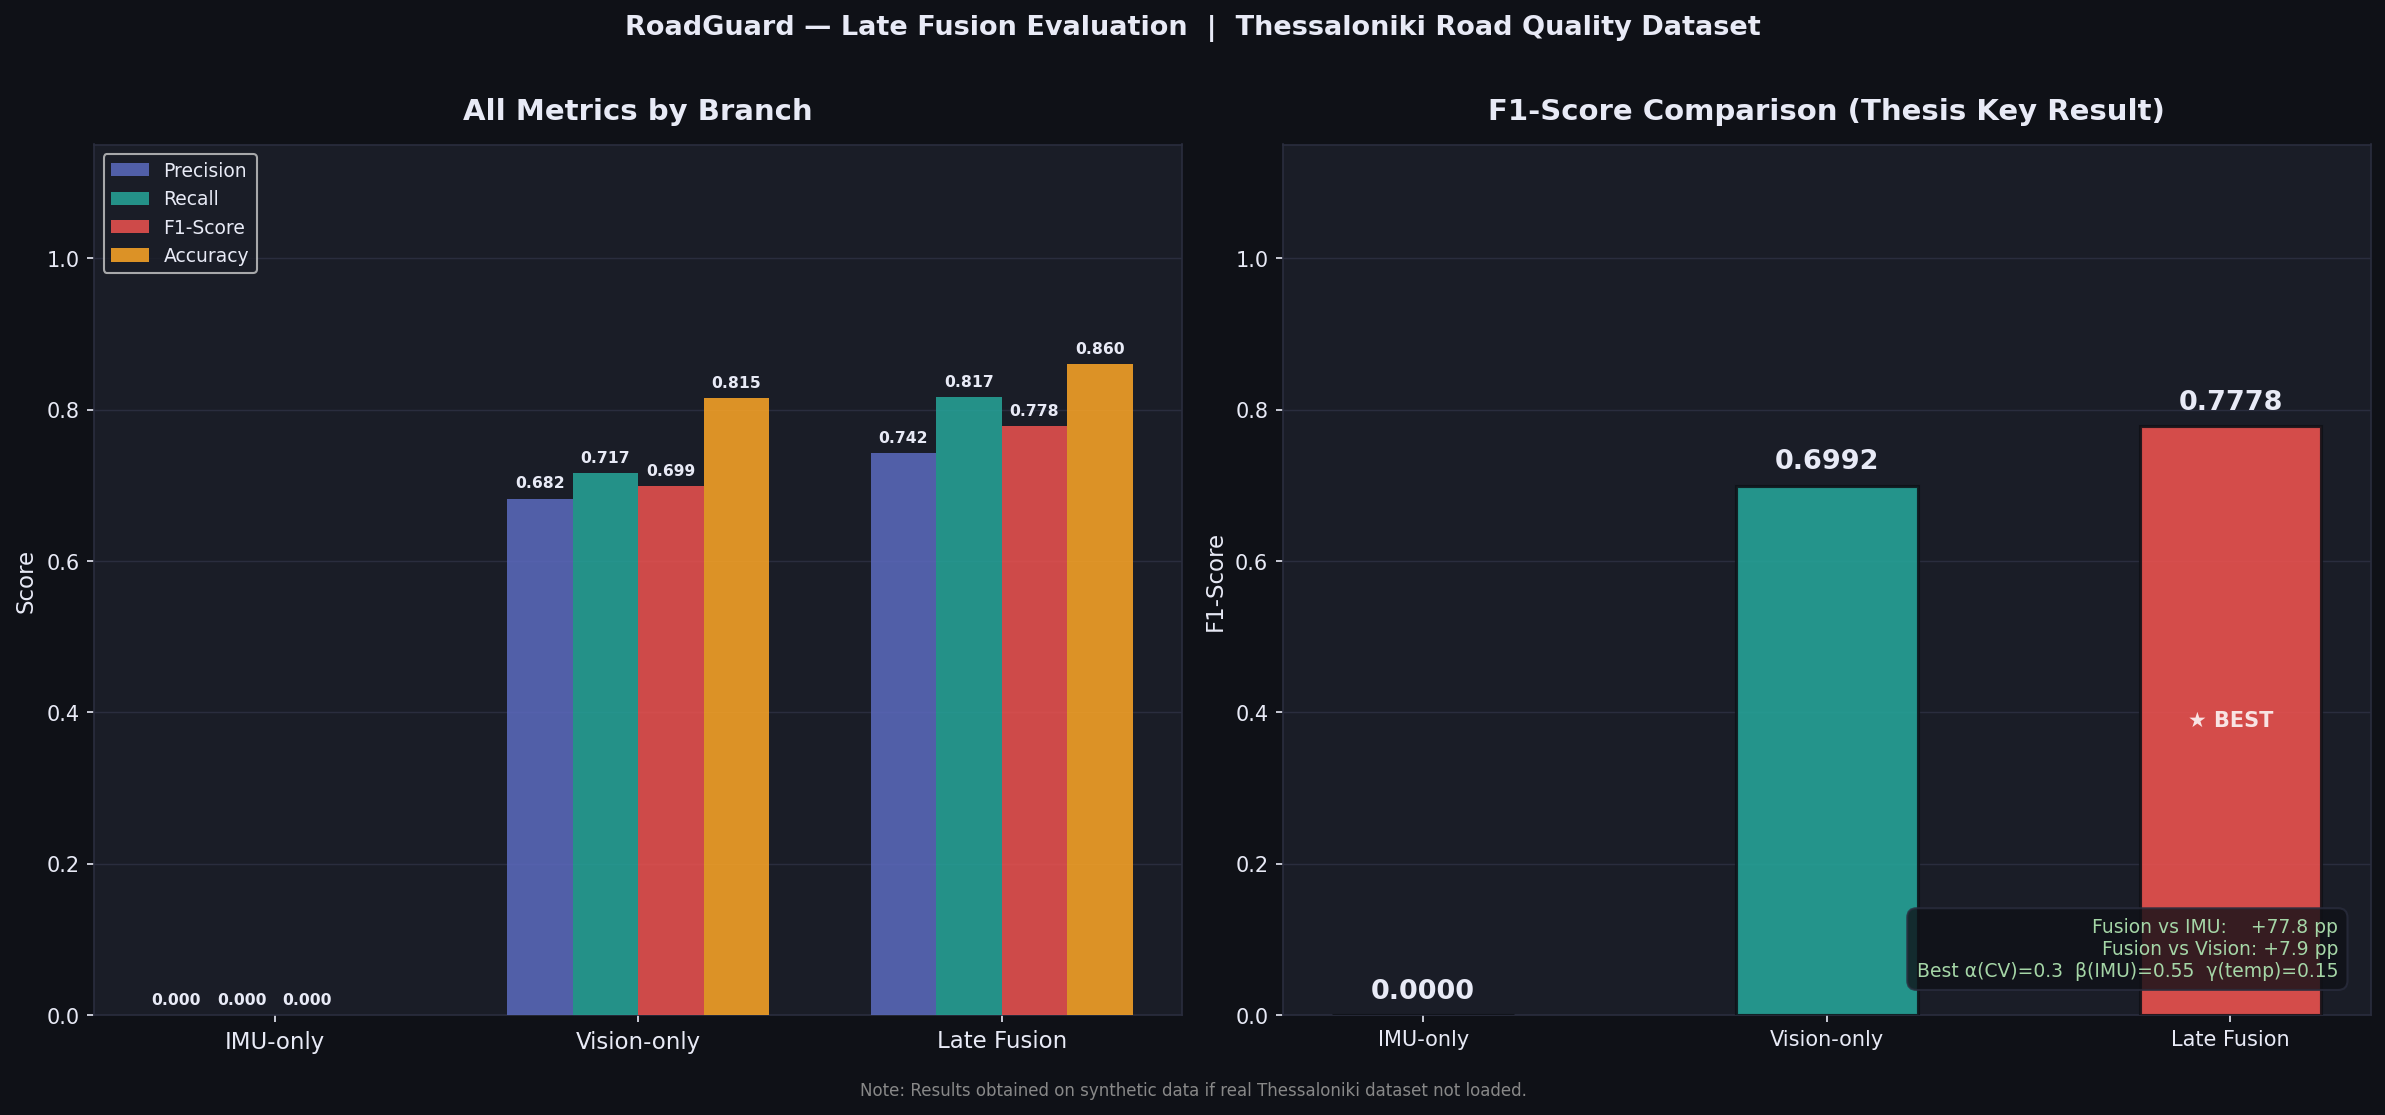

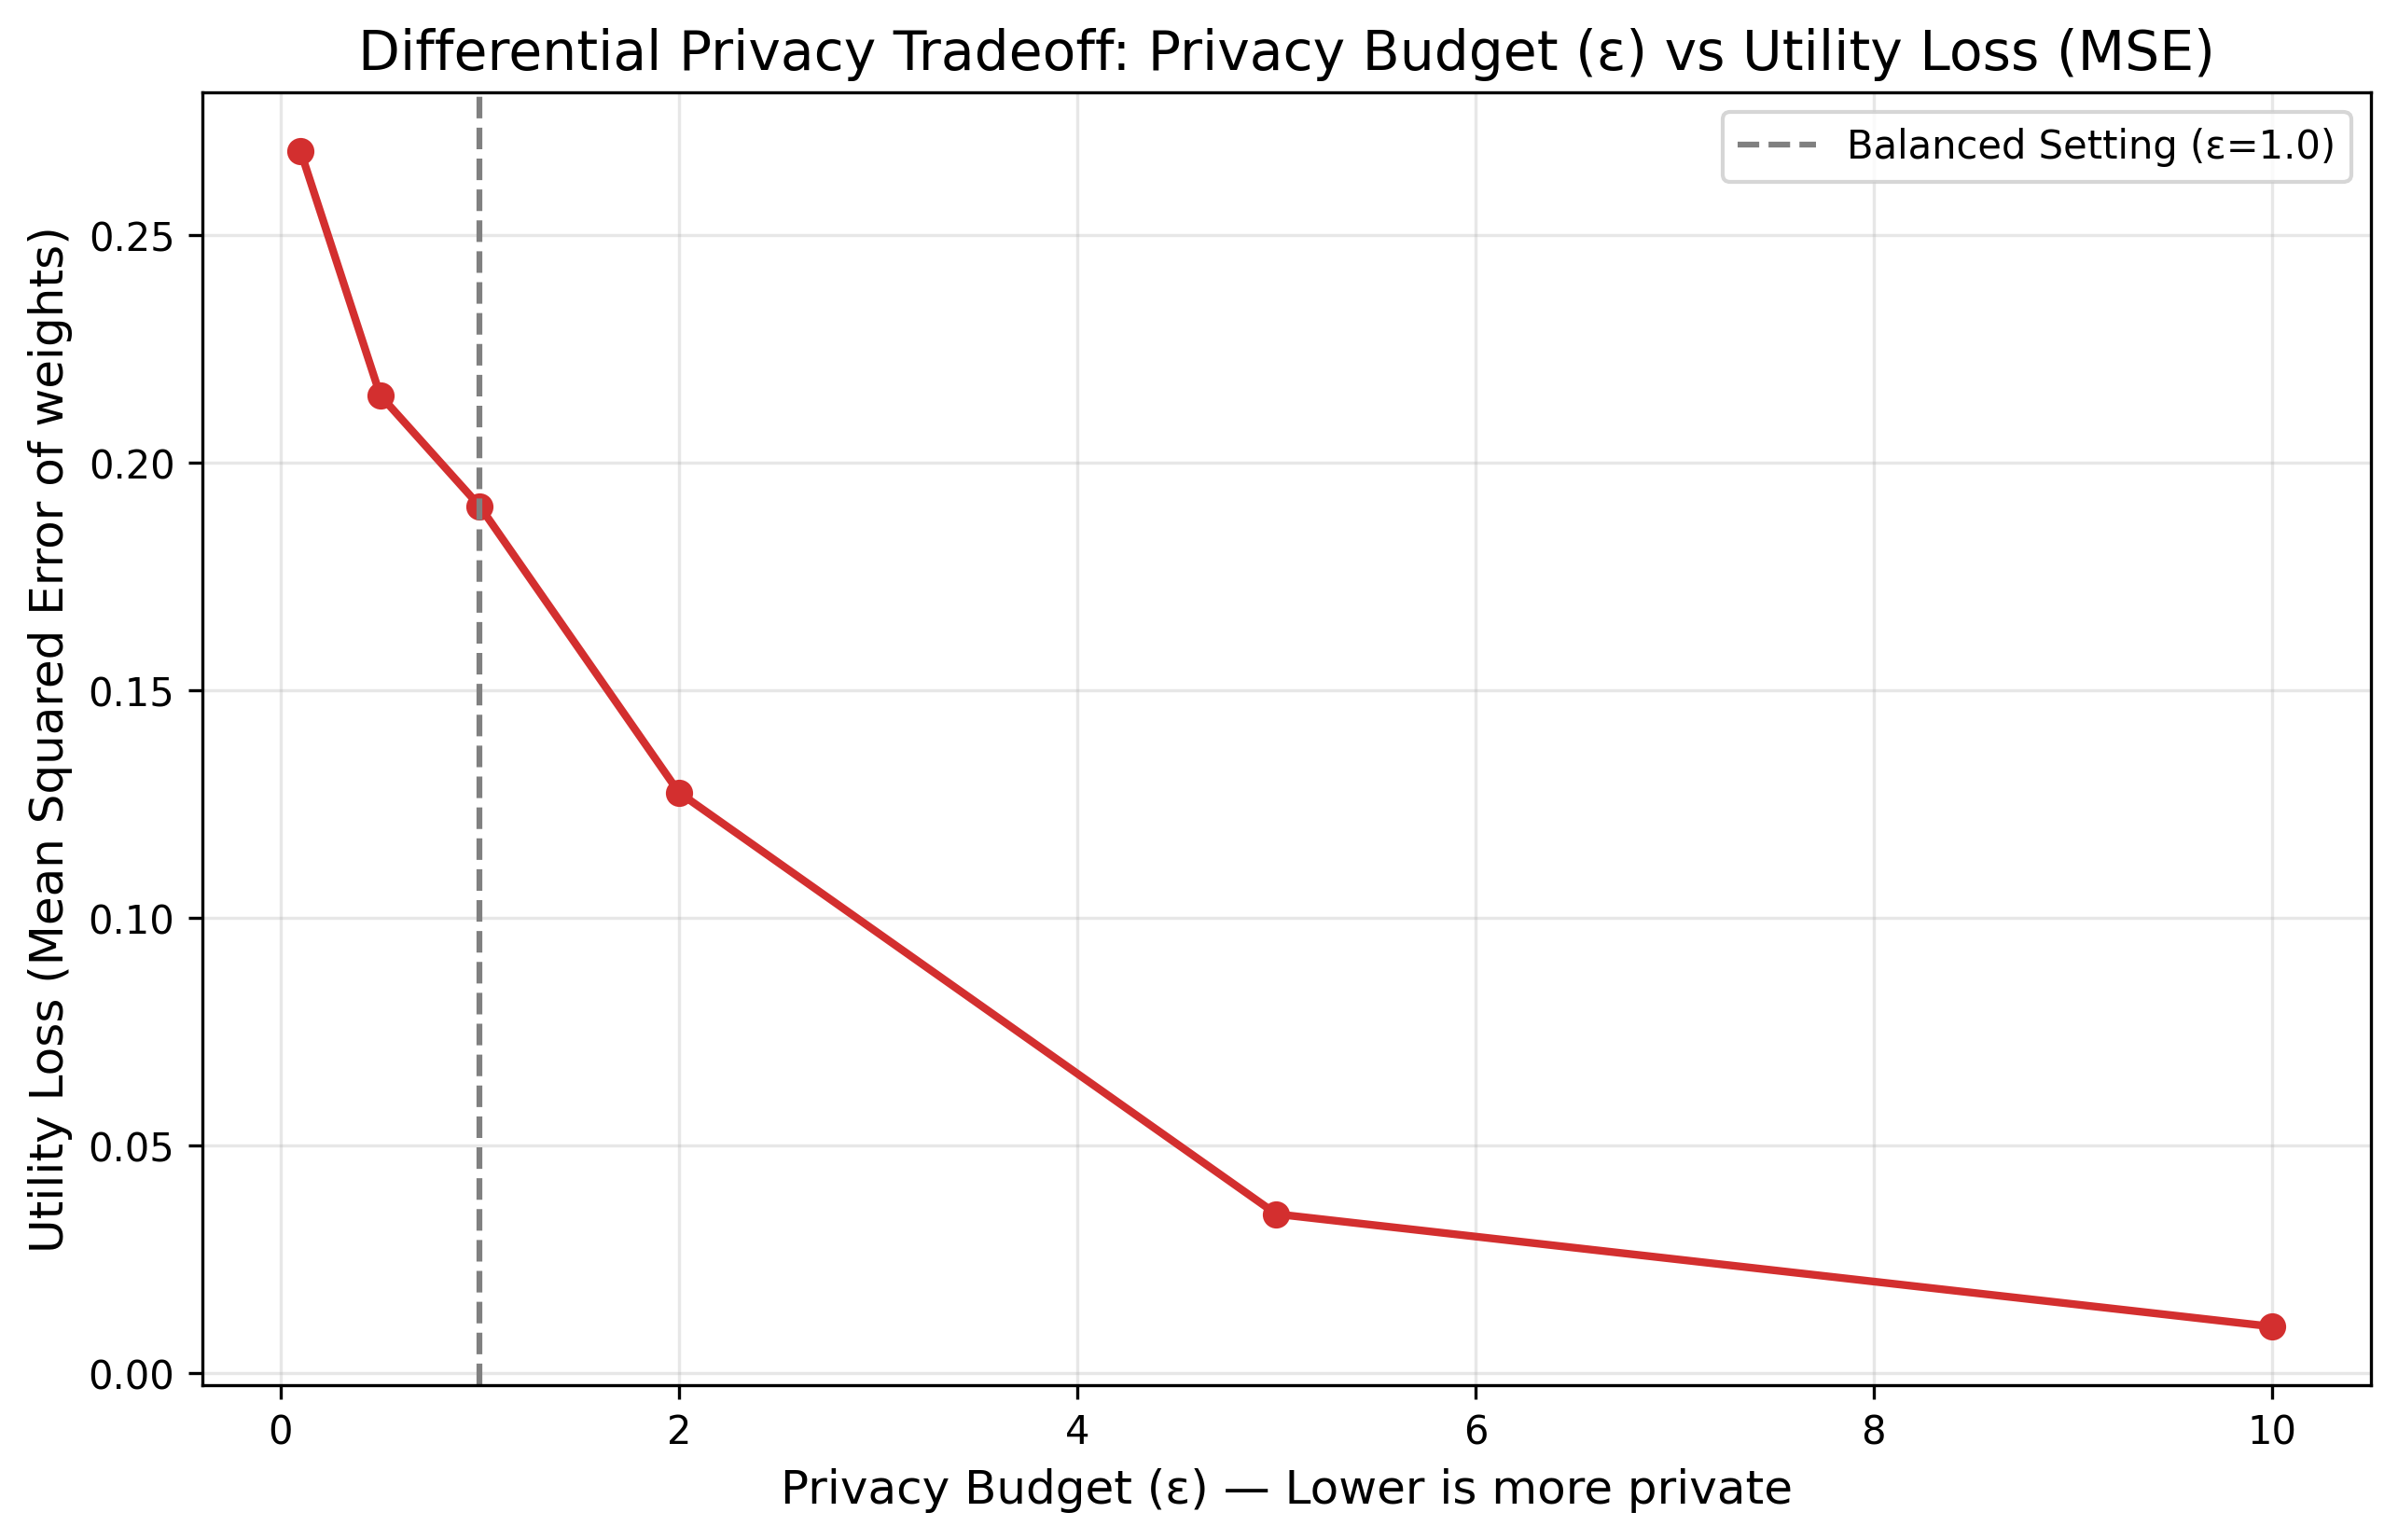

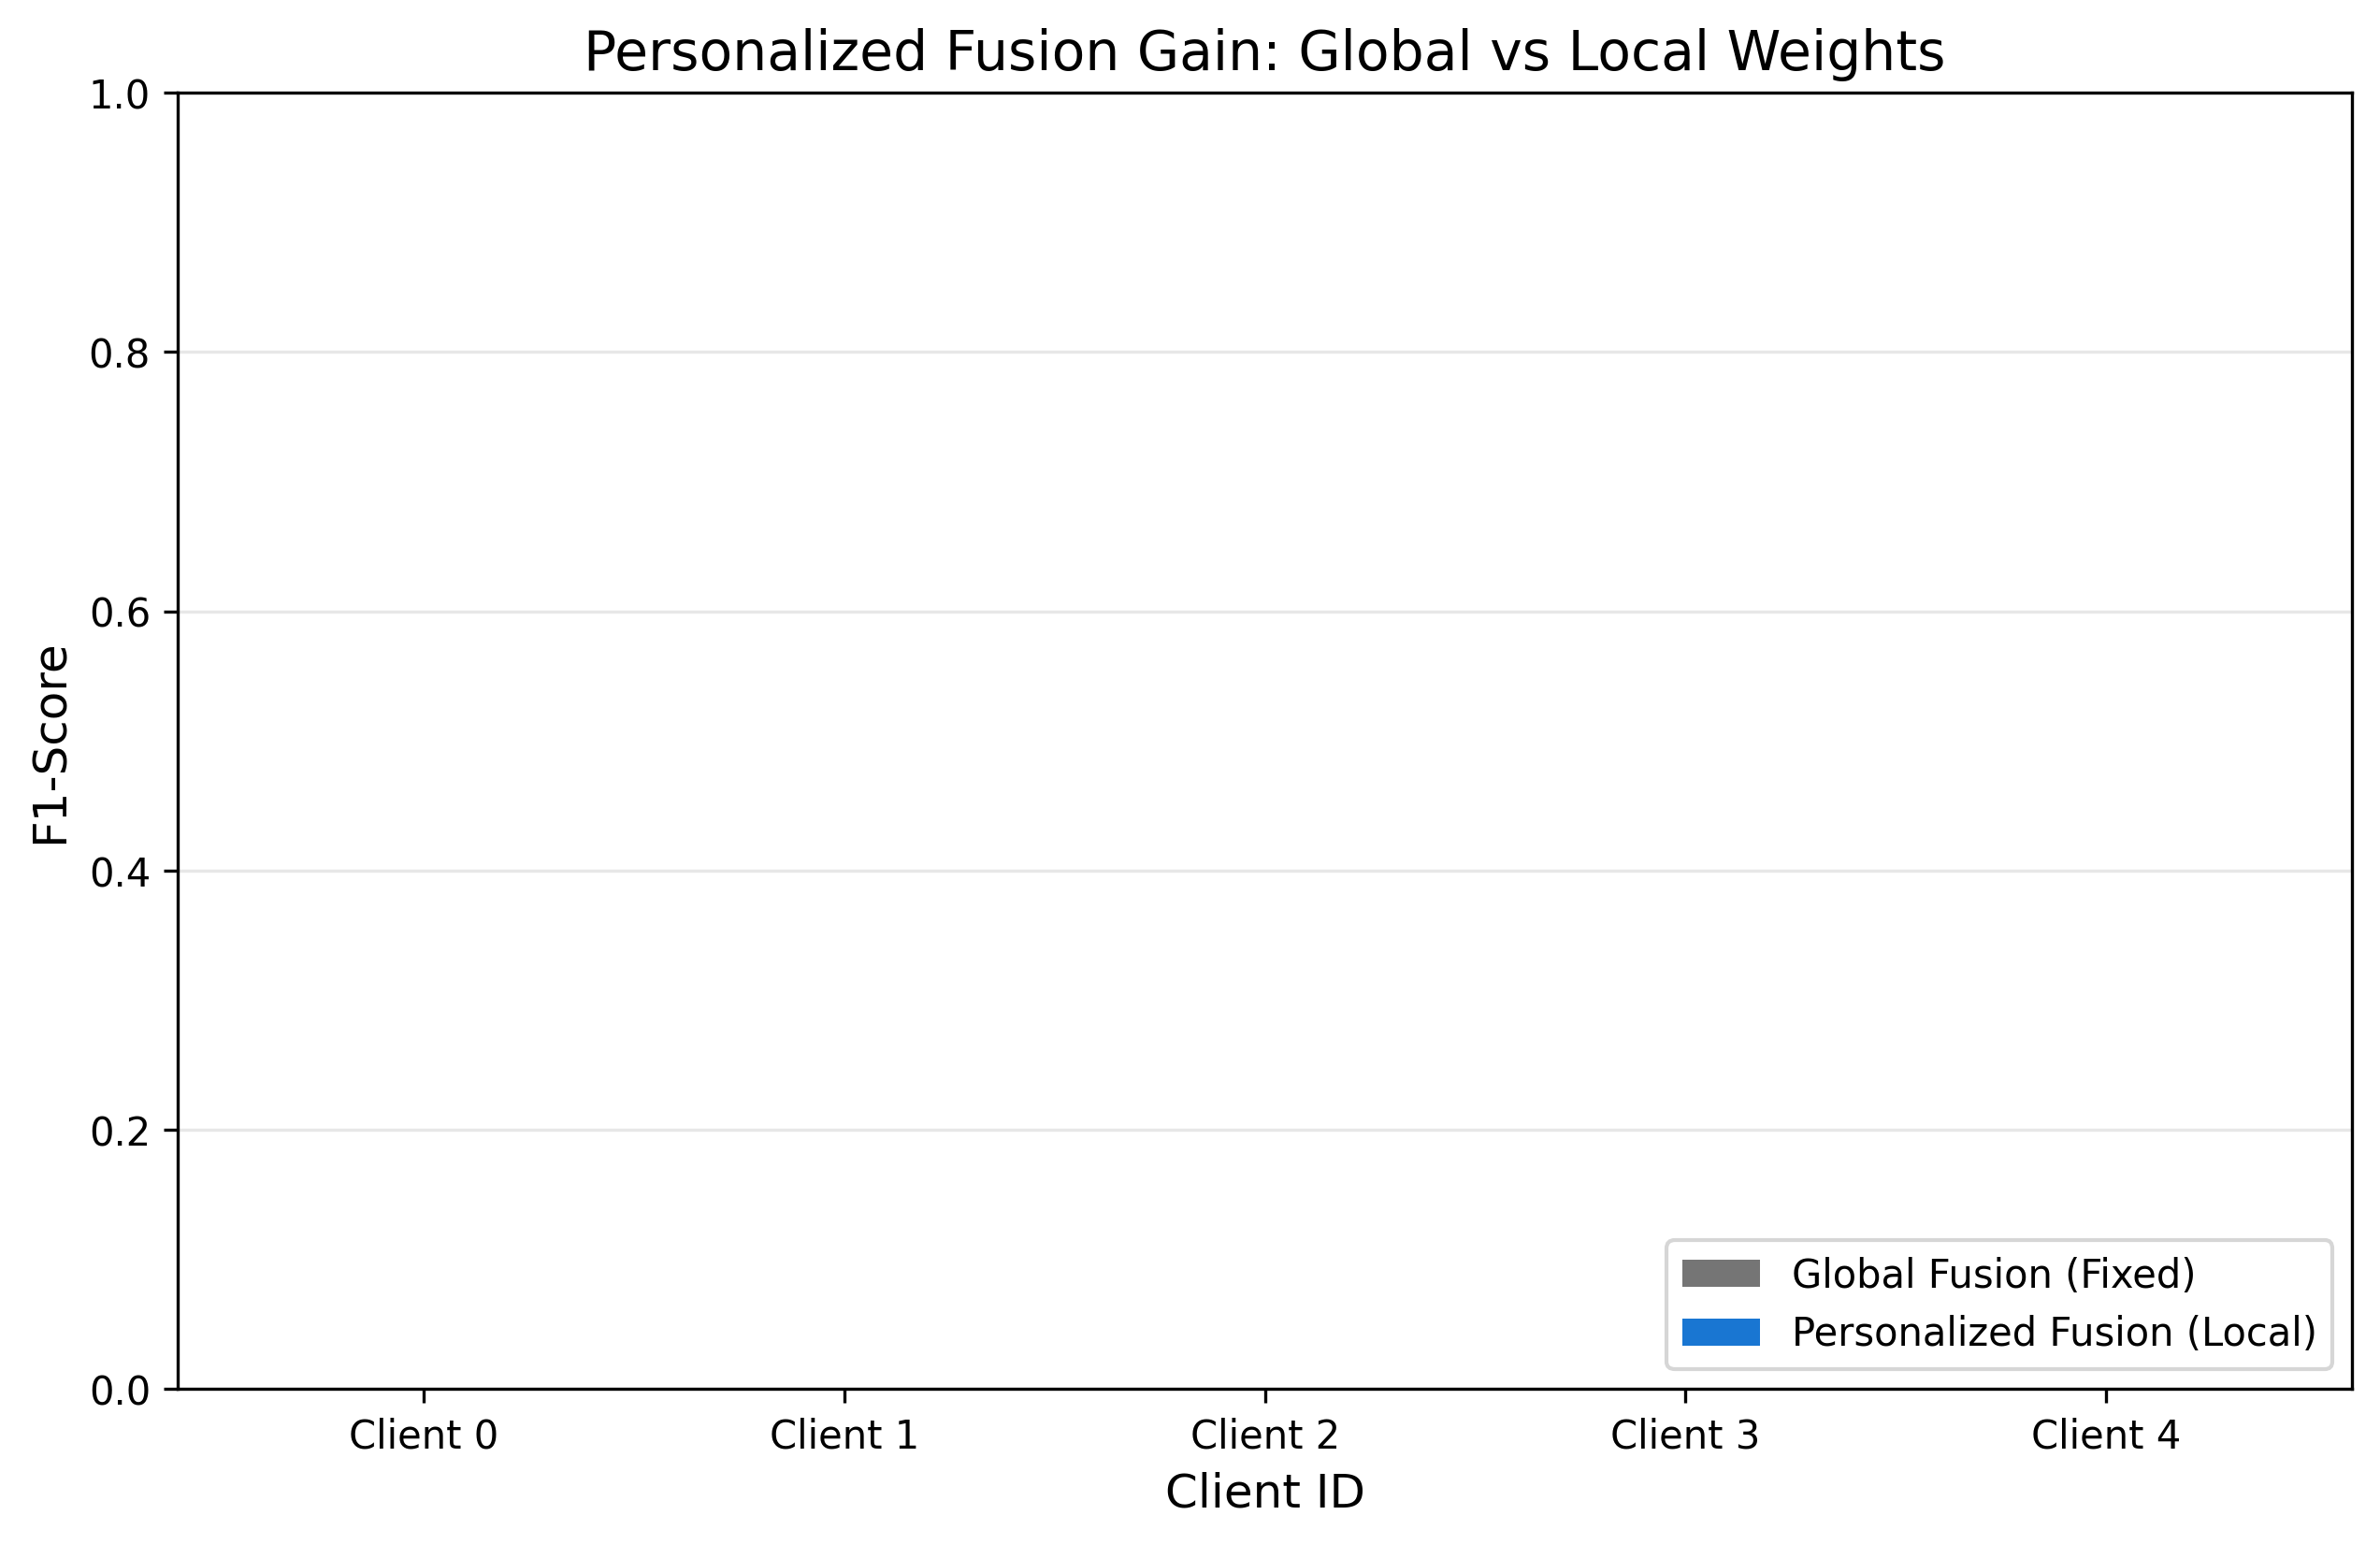

TFLite found and copied from: /content/yolov8n_pothole.tflite


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import os, shutil
from google.colab import files
from IPython.display import Image, display

print('--- THESIS EVALUATION COMPLETE ---')
for img in ['/content/RoadGuard/evaluation/results/comparison_chart.png',
            '/content/RoadGuard/evaluation/results/fl_dp_tradeoff.png',
            '/content/RoadGuard/evaluation/results/fl_full_comparison.png']:
    if os.path.exists(img): display(Image(img))

# Prepare packaging directory
!mkdir -p /content/package/results
!mkdir -p /content/package/weights

# Copy results
shutil.copytree('/content/RoadGuard/evaluation/results', '/content/package/results', dirs_exist_ok=True)

# Copy TFLite Model (Check multiple locations)
tflite_paths = [
    '/content/yolov8n_pothole.tflite',
    '/content/runs/roadguard_v1/weights/best_int8.tflite',
    '/content/runs/roadguard_v1/weights/best_saved_model/best_int8.tflite'
]
for path in tflite_paths:
    if os.path.exists(path):
        shutil.copy(path, '/content/package/yolov8n_pothole.tflite')
        print(f"TFLite found and copied from: {path}")
        break

# Copy PyTorch Model (Best weights)
BEST_MODEL = '/content/runs/roadguard_v1/weights/best.pt'
if os.path.exists(BEST_MODEL):
    shutil.copy(BEST_MODEL, '/content/package/weights/best_100epochs.pt')
elif os.path.exists(os.path.join(DRIVE_SAVE_DIR, 'best_100epochs.pt')):
    shutil.copy(os.path.join(DRIVE_SAVE_DIR, 'best_100epochs.pt'), '/content/package/weights/best_100epochs.pt')

# Archive and Download
shutil.make_archive('/content/RoadGuard_Final_Results', 'zip', '/content/package')
files.download('/content/RoadGuard_Final_Results.zip')